# <center>信号调制方式识别</center>
## 1.背景介绍
　　信号的调制是将原始基带信号的频谱搬移到适合在信道中进行传输的的通带内过程。早期的调制识别是主要借助一些外部仪器进行协调使用，并且加入了人工个人的经验从而进一步识别，这是一种通过分析后人工判定的方式，这种方式在识别中效率低，耗资高，同样精确度也没有保障。大多数无线通信系统中的调制识别过程都具有线性混合、时移、旋转、尺度缩放和卷积的不变性，这种不变性的学习很大程度上类似于视觉领域的学习。
<br>　　本案例针对RML2016.10a_dict数据集并利用VT-CNN2 Mod-Rec Network卷积神经网络对信号实现自动调制方式识别，使用卷积神经网络在图像处理问题中的位移不变性特点，来解决调制识别的问题，使用网络结构来学习匹配滤波器。

## 2.实现过程
step1:　导入相关软件库
<br>step2:　数据集预处理
<br>step3:　搭建神经网络模型
<br>step4:　模型训练
<br>step5:　评估模型并绘制性能图

### 2.1 导入相关软件库

In [1]:
# Import all the things we need ---
%matplotlib inline
import os,random
import numpy as np
from keras.utils import np_utils
import keras.models as models
from keras.layers.core import Reshape,Dense,Dropout,Activation,Flatten
from keras.layers.noise import GaussianNoise
from keras.layers.convolutional import Convolution2D, MaxPooling2D, ZeroPadding2D
from keras.regularizers import *
from keras.optimizers import adam
import matplotlib.pyplot as plt
import seaborn as sns
import _pickle as cPickle
import random, sys, keras
import tensorflow as tf

# physical_devices = tf.config.experimental.list_physical_devices('GPU')
# assert len(physical_devices) > 0
# tf.config.experimental.set_memory_growth(physical_devices[0], True)

Using TensorFlow backend.


### 2.2 数据集预处理
　　RML2016.10a_dict数据集包含220000个数据样本，样本由GNU Radio无线电平台产生。数据集包含数字调制和模拟调制方式共11个类别，分别是8种数字调制BPSK，8PSK，CPFSK，GFSK，PAM4，QAM16，QAM64，QPSK和3种模拟调制AM-DSB，AM-SSB，WBFM，这些数据在不同的SNR（-20dB到18dB，每次均匀间隔2dB，共20个信噪比）上近似均匀分布。下图展示了SNR=-8dB时，不同类别信号的时域表现：
<p align="left"><img width="40%" src="./signal.png" /></p>
　　数据集中共包含如上图所示的11类调制信号，每种调制包含20种信噪比，每种信噪比有1000个样本，每个样本有I和Q两路信号，每路信号包含128个点，所以数据集大小为：220000×2×128。
<br>
<br>(1) 加载数据集

In [2]:
# Load the dataset ...
Xd = cPickle.load(open("RML2016.10a_dict.dat",'rb'),encoding='bytes')
snrs,mods = map(lambda j: sorted(list(set(map(lambda x: x[j], Xd.keys())))), [1,0])
X = []  
lbl = []
for mod in mods:
    for snr in snrs:
        X.append(Xd[(mod,snr)])
        for i in range(Xd[(mod,snr)].shape[0]):  lbl.append((mod,snr))
X = np.vstack(X)

(2) 数据集可视化

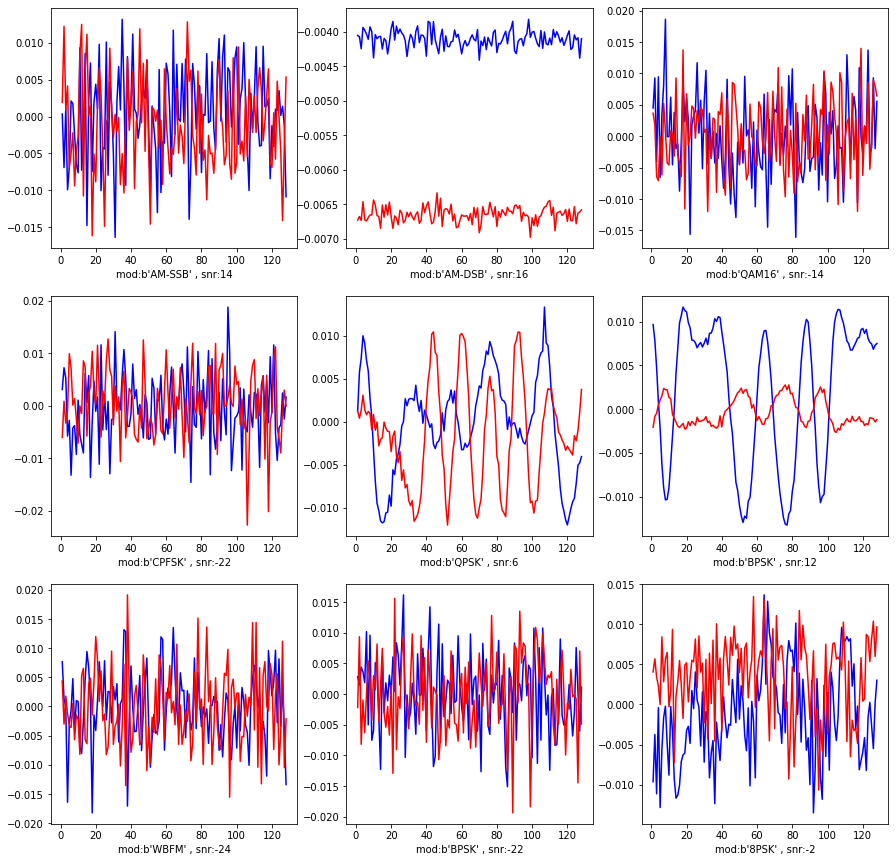

In [3]:
#plot Partial data 
plt.figure(figsize=(15,15))
x = np.linspace(1,128,128)
for i in range(9):
    plt.subplot(3,3,i+1)
    j=random.randint(0,220000)
    y0 = X[j][0]
    y1 = X[j][1]
    plt.plot(x,y0,color='b')
    plt.plot(x,y1,color='r')
    plt.xlabel('mod:%s , snr:%o'%(lbl[j][0],lbl[j][1]))
plt.show()

(3) 将数据集划分为训练集和测试集，并将标签转为one-hot向量

In [4]:
#Partition the data into training and test sets of the form we can train/test on 
# while keeping SNR and Mod labels handy for each
np.random.seed(2016)
n_examples = X.shape[0]
n_train = n_examples * 0.5
train_idx = np.random.choice(range(0,n_examples), size=int(n_train), replace=False)
test_idx = list(set(range(0,n_examples))-set(train_idx))
X_train = X[train_idx]
X_test =  X[test_idx]
def to_onehot(yy):
    yy1 = np.zeros([len(yy), max(yy)+1])
    yy1[np.arange(len(yy)),yy] = 1
    return yy1
Y_train = to_onehot(list(map(lambda x: mods.index(lbl[x][0]), train_idx)))
Y_test = to_onehot(list(map(lambda x: mods.index(lbl[x][0]), test_idx)))

### 2.3 搭建神经网络模型
　　本案例构建的模型是一个四层的卷积神经网络，该网络具有两层卷积层和两个全连接层，前三层使用ReLU作为激活函数，在输出层使用SoftMax激活函数。输入层将I/Q数据看成单通道的2×128大小的图像数据，输出层进行分类，将出11个不同的概率值。
<br>　　整个卷积神经网络的结构如下图所示：
<p align="left"><img width="40%" src="./network.png" /></p>


In [5]:
in_shp = list(X_train.shape[1:])
print (X_train.shape, in_shp)
classes = mods

#  - Reshape [N,2,128] to [N,1,2,128] on input
#  - Pass through 2 2DConv/ReLu layers
#  - Pass through 2 Dense layers (ReLu and Softmax)
#  - Perform categorical cross entropy optimization

dr = 0.5 # dropout rate
model = models.Sequential()
model.add(Reshape([1]+in_shp, input_shape=in_shp))
model.add(ZeroPadding2D((2, 2)))
model.add(Convolution2D(256, 1, 3, border_mode='valid', activation="relu", name="conv1", init='glorot_uniform'))
model.add(Dropout(dr))
model.add(ZeroPadding2D((2, 2))) 
model.add(Convolution2D(80, 2, 3, border_mode="valid", activation="relu", name="conv2", init='glorot_uniform'))
model.add(Dropout(dr))
model.add(Flatten())
model.add(Dense(256, activation='relu', init='he_normal', name="dense1"))
model.add(Dropout(dr))
model.add(Dense( len(classes), init='he_normal', name="dense2" ))
model.add(Activation('softmax'))
model.add(Reshape([len(classes)]))
model.compile(loss='categorical_crossentropy', optimizer='adam')
model.summary()

W1008 10:38:32.809379 140355745081152 deprecation_wrapper.py:119] From /usr/local/iCompute/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W1008 10:38:32.836846 140355745081152 deprecation_wrapper.py:119] From /usr/local/iCompute/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

/usr/local/iCompute/lib/python3.6/site-packages/ipykernel_launcher.py:14: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(256, (1, 3), activation="relu", name="conv1", padding="valid", kernel_initializer="glorot_uniform")`
  
W1008 10:38:32.856569 140355745081152 deprecation_wrapper.py:119] From /usr/local/iCompute/lib/python3.6/site-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W1008 10:38:

(110000, 2, 128) [2, 128]


/usr/local/iCompute/lib/python3.6/site-packages/ipykernel_launcher.py:22: UserWarning: Update your `Dense` call to the Keras 2 API: `Dense(11, name="dense2", kernel_initializer="he_normal")`
W1008 10:38:33.031168 140355745081152 deprecation_wrapper.py:119] From /usr/local/iCompute/lib/python3.6/site-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.



_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_1 (Reshape)          (None, 1, 2, 128)         0         
_________________________________________________________________
zero_padding2d_1 (ZeroPaddin (None, 5, 6, 128)         0         
_________________________________________________________________
conv1 (Conv2D)               (None, 5, 4, 256)         98560     
_________________________________________________________________
dropout_1 (Dropout)          (None, 5, 4, 256)         0         
_________________________________________________________________
zero_padding2d_2 (ZeroPaddin (None, 9, 8, 256)         0         
_________________________________________________________________
conv2 (Conv2D)               (None, 8, 6, 80)          122960    
_________________________________________________________________
dropout_2 (Dropout)          (None, 8, 6, 80)          0         
__________

### 2.4 模型训练
(1) 设置超参数
<br>(2) 定义模型保存路径
<br>(3) 进行模型训练
<br>(4) 保存模型

In [6]:
# Set up some params 
nb_epoch = 100     # number of epochs to train on
batch_size = 1024  # training batch size

#Train the model
history = model.fit(X_train,
    Y_train,
    batch_size=batch_size,
    epochs=nb_epoch,
    validation_data=(X_test, Y_test),
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=0, mode='auto')
    ])

# we re-load the best weights once training is finished


W1008 10:38:33.377215 140355745081152 deprecation.py:323] From /usr/local/iCompute/lib/python3.6/site-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 110000 samples, validate on 110000 samples
Epoch 1/100
110000/110000 [==============================] - 19s 173us/step - loss: 2.2272 - val_loss: 2.0875
Epoch 2/100
110000/110000 [==============================] - 13s 121us/step - loss: 1.9711 - val_loss: 1.8447
Epoch 3/100
110000/110000 [==============================] - 13s 120us/step - loss: 1.8403 - val_loss: 1.7720
Epoch 4/100
110000/110000 [==============================] - 13s 120us/step - loss: 1.7662 - val_loss: 1.6928
Epoch 5/100
110000/110000 [==============================] - 13s 120us/step - loss: 1.7099 - val_loss: 1.6548
Epoch 6/100
110000/110000 [==============================] - 13s 120us/step - loss: 1.6730 - val_loss: 1.6246
Epoch 7/100
110000/110000 [==============================] - 13s 119us/step - loss: 1.6473 - val_loss: 1.6053
Epoch 8/100
110000/110000 [==============================] - 13s 120us/step - loss: 1.6288 - val_loss: 1.5830
Epoch 9/100
110000/110000 [==============================] - 13s 120

In [8]:
"""
tf.saver.restore(...)
"""
# 上面省略了模型的加载的代码
from keras import backend as K
import shutil
#设置导出的路径
export_path_base = "saved_model"
export_version = '1';
export_path = os.path.join(export_path_base,export_version)
if os.path.exists(export_path):
      shutil.rmtree(export_path)
        
print('Exporting trained model to', export_path)
builder = tf.compat.v1.saved_model.builder.SavedModelBuilder(export_path)
print('step1 => builder  created successfully')
# 构建signature_def_map，参数为模型的输入与输出
tensor_info_input = tf.compat.v1.saved_model.utils.build_tensor_info(model.input)
tensor_info_output = tf.compat.v1.saved_model.utils.build_tensor_info(model.output)
# 定义模型的类型
prediction_signature = (
    tf.compat.v1.saved_model.signature_def_utils.build_signature_def(
        inputs={'inputs': tensor_info_input},
        outputs={'outputs': tensor_info_output},
        method_name=tf.saved_model.PREDICT_METHOD_NAME))

print('step2 => prediction_signature created successfully')
builder.add_meta_graph_and_variables(
    # tags:SERVING,TRAINING,EVAL,GPU,TPU
    K.get_session(), [tf.saved_model.SERVING],
    signature_def_map={
        'serving_default': prediction_signature,
    })

print('step3 => builder successfully add meta graph and variables\nNext is to export model...')
#builder.save(as_text=True)
builder.save()
print('Done exporting!')


Exporting trained model to saved_model/1
step1 => builder  created successfully
step2 => prediction_signature created successfully
step3 => builder successfully add meta graph and variables
Next is to export model...
Done exporting!


In [9]:
!saved_model_cli show --dir /home/user/test/RML/saved_model/1 --all

2021-10-08 10:47:18.133495: I tensorflow/stream_executor/platform/default/dso_loader.cc:42] Successfully opened dynamic library libcudart.so.10.1

MetaGraphDef with tag-set: 'serve' contains the following SignatureDefs:

signature_def['serving_default']:
  The given SavedModel SignatureDef contains the following input(s):
    inputs['inputs'] tensor_info:
        dtype: DT_FLOAT
        shape: (-1, 2, 128)
        name: reshape_1_input:0
  The given SavedModel SignatureDef contains the following output(s):
    outputs['outputs'] tensor_info:
        dtype: DT_FLOAT
        shape: (-1, 11)
        name: reshape_2/Reshape:0
  Method name is: tensorflow/serving/predict


### 2.5评估模型并绘制性能图
(1)对测试集进行评估

In [52]:
# Show simple version of performance
score = model.evaluate(X_test, Y_test,  verbose=1, batch_size=batch_size)
print (score)

110000/110000 [==============================] - 3s 32us/step
1.4831827419281005


(2)绘制损失函数图像

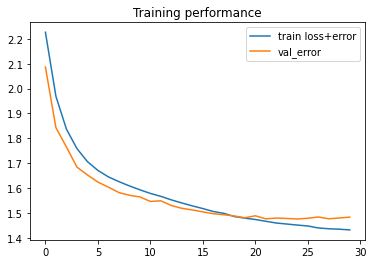

In [53]:
# Show loss curves 
plt.figure()
plt.title('Training performance')
plt.plot(history.epoch, history.history['loss'], label='train loss+error')
plt.plot(history.epoch, history.history['val_loss'], label='val_error')
plt.legend()

(3)定义绘制混淆矩阵的函数

In [54]:
def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Blues, labels=[]):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

(4) 对测试集进行预测并生成混淆矩阵

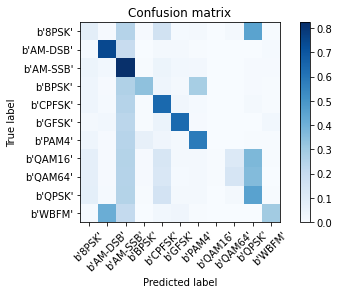

In [55]:
#  Predict 
test_Y_hat = model.predict(X_test, batch_size=batch_size)
conf = np.zeros([len(classes),len(classes)])
confnorm = np.zeros([len(classes),len(classes)])
for i in range(0,X_test.shape[0]):
    j = list(Y_test[i,:]).index(1)
    k = int(np.argmax(test_Y_hat[i,:]))
    conf[j,k] = conf[j,k] + 1
for i in range(0,len(classes)):
    confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])
    
# Plot confusion matrix
plot_confusion_matrix(confnorm, labels=classes)

(5) 生成不同snr下的混淆矩阵

SNR=-20  Overall Accuracy:0.09862763 
SNR=-18  Overall Accuracy:0.09609446 
SNR=-16  Overall Accuracy:0.10130246 
SNR=-14  Overall Accuracy:0.10122699 
SNR=-12  Overall Accuracy:0.13509572 
SNR=-10  Overall Accuracy:0.17807002 
SNR=-8  Overall Accuracy:0.27650193 
SNR=-6  Overall Accuracy:0.40267595 
SNR=-4  Overall Accuracy:0.51090573 
SNR=-2  Overall Accuracy:0.55841800 
SNR=0  Overall Accuracy:0.58102190 
SNR=2  Overall Accuracy:0.59469284 
SNR=4  Overall Accuracy:0.60664464 
SNR=6  Overall Accuracy:0.62148014 
SNR=8  Overall Accuracy:0.62506763 
SNR=10  Overall Accuracy:0.62622951 
SNR=12  Overall Accuracy:0.61940974 
SNR=14  Overall Accuracy:0.62852925 
SNR=16  Overall Accuracy:0.62805430 
SNR=18  Overall Accuracy:0.63078308 


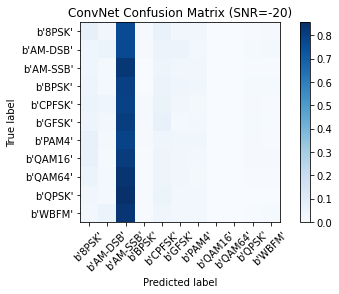

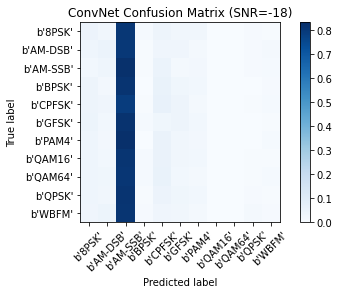

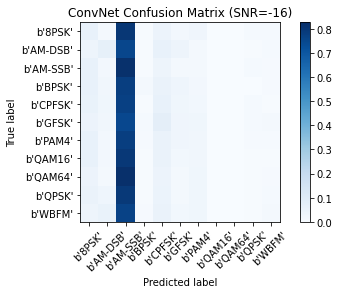

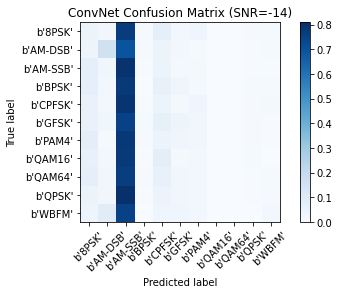

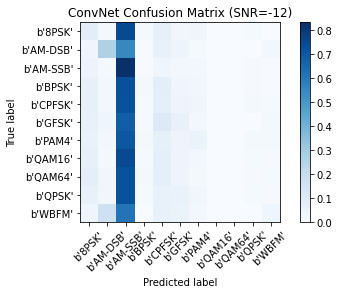

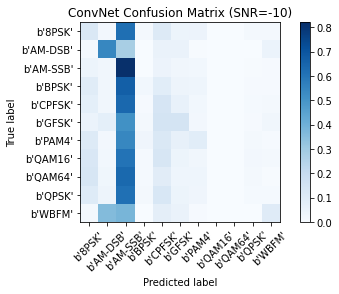

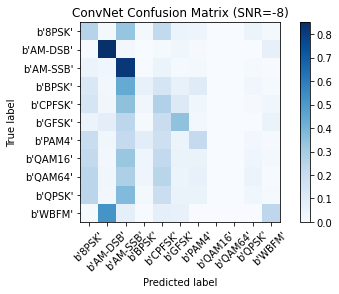

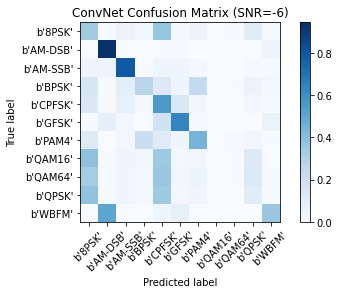

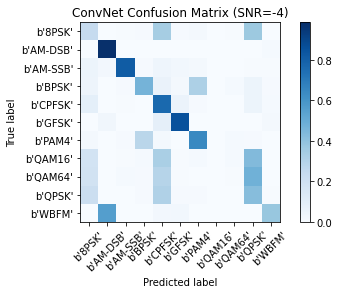

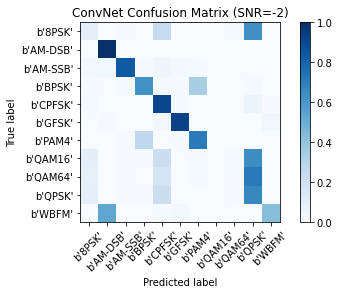

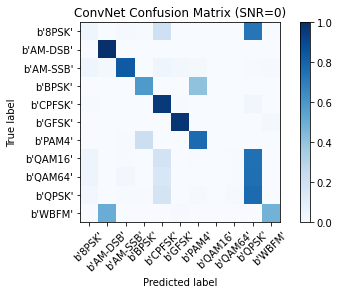

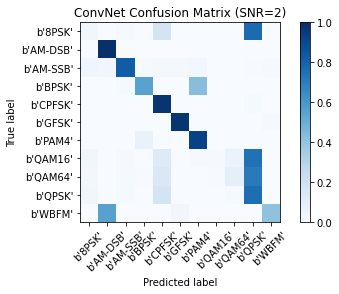

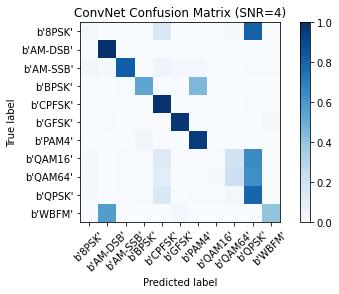

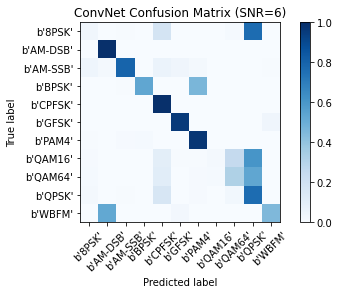

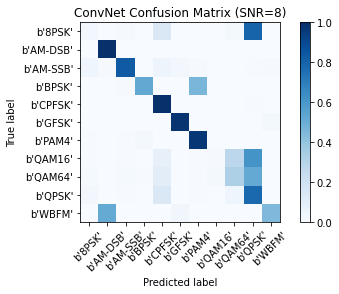

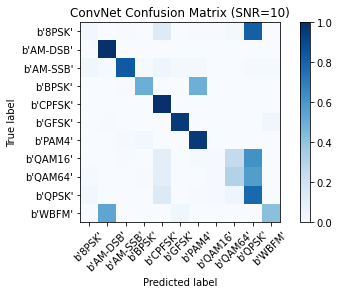

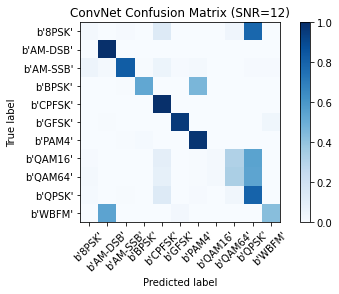

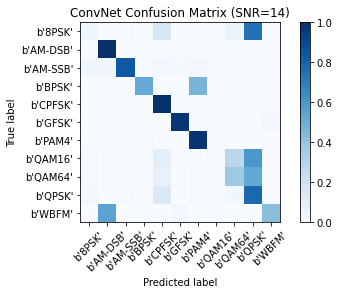

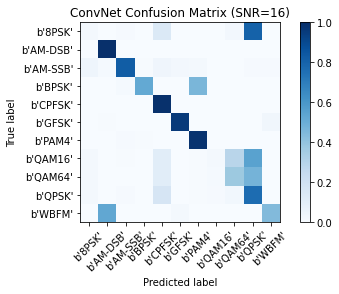

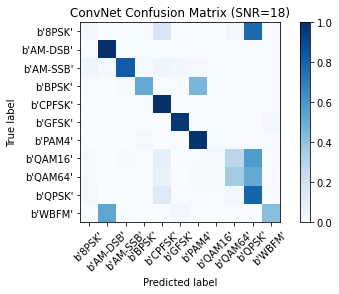

In [56]:
# Plot confusion matrix
acc = {}
for snr in snrs:
    
    # extract classes @ SNR
    test_SNRs = list(map(lambda x: lbl[x][1], test_idx))
    test_X_i = X_test[np.where(np.array(test_SNRs)==snr)]
    test_Y_i = Y_test[np.where(np.array(test_SNRs)==snr)]    

    # estimate classes
    test_Y_i_hat = model.predict(test_X_i)
    conf = np.zeros([len(classes),len(classes)])
    confnorm = np.zeros([len(classes),len(classes)])
    for i in range(0,test_X_i.shape[0]):
        j = list(test_Y_i[i,:]).index(1)
        k = int(np.argmax(test_Y_i_hat[i,:]))
        conf[j,k] = conf[j,k] + 1
    for i in range(0,len(classes)):
        confnorm[i,:] = conf[i,:] / np.sum(conf[i,:])
    plt.figure()
    plot_confusion_matrix(confnorm, labels=classes, title="ConvNet Confusion Matrix (SNR=%d)"%(snr))
    
    cor = np.sum(np.diag(conf))
    ncor = np.sum(conf) - cor
    print ("SNR=%d  Overall Accuracy:%0.8f "%(snr,cor / (cor+ncor)))
    acc[snr] = 1.0*cor/(cor+ncor)

(6) 保存不同snr下的模型预测精确度acc，并绘制精确度图像

{-20: 0.09862763037511436, -18: 0.096094459582198, -16: 0.10130246020260492, -14: 0.10122699386503067, -12: 0.13509571558796718, -10: 0.17807001954860494, -8: 0.2765019290832262, -6: 0.40267595307917886, -4: 0.51090573012939, -2: 0.5584179970972424, 0: 0.581021897810219, 2: 0.5946928389676481, 4: 0.6066446402349486, 6: 0.6214801444043321, 8: 0.6250676284941389, 10: 0.6262295081967213, 12: 0.6194097410827449, 14: 0.6285292489389186, 16: 0.6280542986425339, 18: 0.6307830783078308}


Text(0.5, 1.0, 'CNN2 Classification Accuracy on RadioML 2016.10 Alpha')

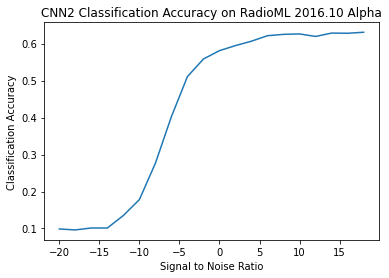

In [57]:
# Save results to a pickle file for plotting later
print (acc)
fd = open('results_cnn2_d0.5.dat','wb')
cPickle.dump( ("CNN2", 0.5, acc) , fd )

# Plot accuracy curve
plt.plot(snrs, list(map(lambda x: acc[x], snrs)))
plt.xlabel("Signal to Noise Ratio")
plt.ylabel("Classification Accuracy")
plt.title("CNN2 Classification Accuracy on RadioML 2016.10 Alpha")